# Finetuning pretrained - Gan 

I have used a pretrained model from kaggle that is made for 64\*64 images. So, I have scaled the images to 64\*64.

Moreover, in this file, I have used normalisation to \[0,1\] to see the difference.

In [ ]:
import pandas as pd
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet'}
train_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["train"])
test_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import io

In [ ]:
class Cifar10Dataset(Dataset):
    def __init__(self, dataset ,input_transform, target_transform):
        self.x = [input_transform(dataset['img'][i]["bytes"]) for i in range(len(dataset['img']))]
        self.y = torch.LongTensor([target_transform(l) for l in dataset['label']])

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]

In [ ]:
def input_transform(x):
    img = Image.open(io.BytesIO(x)).resize((64,64))
    d = torch.from_numpy(np.asarray(img,dtype=np.float32)).transpose(2,1).transpose(0,1)/255
    return d

In [ ]:
train_data = Cifar10Dataset(train_dataset,input_transform,lambda x: x)
test_data = Cifar10Dataset(test_dataset,input_transform,lambda x: x)

## DCGAN

In [ ]:
import torch.nn.functional as F
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.conv1 = nn.ConvTranspose2d(100, 64*8, 4, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(64*8)
        self.conv2 = nn.ConvTranspose2d(64*8, 64*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64*4)
        self.conv3 = nn.ConvTranspose2d(64*4, 64*2, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64*2)
        self.conv4 = nn.ConvTranspose2d(64*2, 64, 4, 2, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        x = F.relu(self.bn3(self.conv3(x)), inplace=True)
        x = F.relu(self.bn4(self.conv4(x)), inplace=True)
        return torch.tanh(self.conv5(x))

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 64*2, 4, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64*2)
        self.conv3 = nn.Conv2d(64*2, 64*4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64*4)
        self.conv4 = nn.Conv2d(64*4, 64*8, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64*8)
        self.conv5 = nn.Conv2d(64*8, 1, 4, 1, 0, bias=False)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn1(self.conv2(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn2(self.conv3(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn3(self.conv4(x)), negative_slope=0.2, inplace=True)
        return torch.sigmoid(self.conv5(x))

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
checkpoint = torch.load("./150epochs.chkpt", map_location=device)
generator.load_state_dict(checkpoint['generator_state_dict'])
discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

<All keys matched successfully>

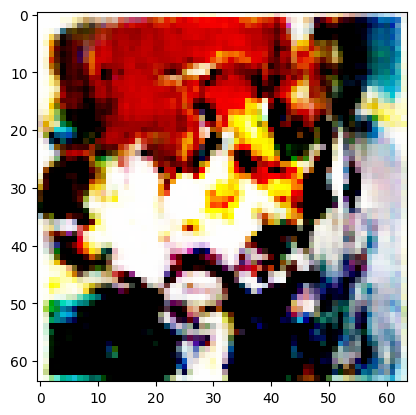

In [ ]:
z = torch.randn((1,100,1,1)).to(device)
x = generator(z)
plt.imshow(x.transpose(1,2).transpose(2,3)[0].detach().cpu().numpy())

In [ ]:
discriminator(x),x.shape

(tensor([[[[0.0003]]]], device='cuda:0', grad_fn=<SigmoidBackward0>),
 torch.Size([1, 3, 64, 64]))

The above generator is made for 64\*64 and the discriminator is also made for 64\*64.
As we have 32*32, The images are scaled up.

In [ ]:
batch_size = 4096

train_dataloader = DataLoader(train_data,batch_size=batch_size)

In [ ]:
import os
import gc

#os.mkdir("finetuning_pretrained_model_01")
gc.collect()
torch.cuda.empty_cache()

In [30]:
max_epoch = 100

generator.train()
discriminator.train()

criterion = nn.BCELoss().to(device)
rgenerator = torch.Generator(device='cuda')


lr = 1e-5
beta1 = 0.5

generator_optim = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
discriminator_optim = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
generator_optim.load_state_dict(checkpoint['generator_optim_state_dict'])
discriminator_optim.load_state_dict(checkpoint['discriminator_optim_state_dict'])
for n in range(max_epoch):
    loss_ = 0
    D_t = 0
    loss_2 = 0
    for (x,y) in train_dataloader:
        discriminator_optim.zero_grad()
        x = x.to(device)
        y = y.to(device)
        labels = torch.ones((x.shape[0])).to(device)
        pred = discriminator(x).reshape(-1)
        D_t+=pred.sum()
        loss1 = criterion(pred,labels)
        loss1.backward()
        loss_+=loss1.item()
        discriminator_optim.step()
        z = torch.randn((y.shape[0],100,1,1),generator = rgenerator,device = device)
        D_f = 0
        discriminator_optim.zero_grad()
        y = generator(z)
        pred = discriminator(y.detach()).reshape(-1)
        D_f+=pred.sum()
        labels = torch.zeros(y.shape[0]).to(device)
        loss2 = criterion(pred,labels)
        loss2.backward()
        loss_ +=loss2.item()
        net_loss = loss1 + loss2
        discriminator_optim.step()
        generator_optim.zero_grad()
        pred = discriminator(y).reshape(-1)
        labels[:] = 1
        loss2 = criterion(pred,labels)
        loss2.backward()
        loss_2+=loss2.item()
        generator_optim.step()

    print(D_t.item()/len(train_data),D_f.item()/len(train_data))
    print(n,loss_,loss_2)
    if (n+1)%20 == 0:
        torch.save({
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'generator_optim_state_dict' : generator_optim.state_dict(),
            'discriminator_optim_state_dict' : discriminator_optim.state_dict(),}, f"finetuning_pretrained_model_01/{n+1}epochs.chkpt")


0.888576796875 0.0016608012390136719
0 3.66556815803051 58.14133358001709
0.876942734375 0.0013005638122558594
1 3.913618378341198 59.07681846618652
0.89497484375 0.0012779086303710938
2 3.1713551431894302 58.183337688446045
0.90307109375 0.0015376881408691405
3 3.0475167110562325 58.97918462753296
0.8789103125 0.0013270449829101564
4 3.797841839492321 63.51595592498779
0.907951796875 0.001180767059326172
5 2.7417090609669685 62.22070789337158
0.66669125 0.003451437683105469
6 27.49031773209572 79.79917430877686
0.8435203125 0.0018553652954101563
7 5.211709171533585 58.29592943191528
0.901923828125 0.0014031222534179688
8 3.049669474363327 59.98538303375244
0.905375078125 0.0009621278381347656
9 2.8704643100500107 59.4637188911438
0.911316640625 0.0012869459533691406
10 2.6612952426075935 60.16642904281616
0.694603515625 0.004878190307617188
11 20.338419549167156 72.88518857955933
0.876806953125 0.0014320124816894532
12 3.894394539296627 59.619935512542725
0.901531015625 0.000932167129

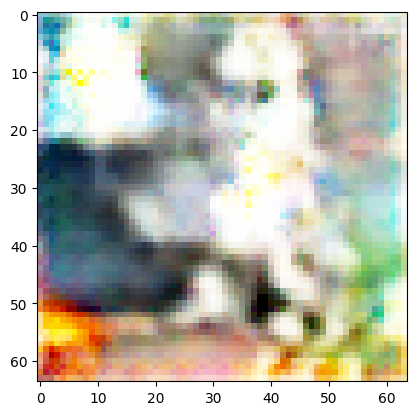

In [31]:
z = torch.randn((1,100,1,1)).to(device)*5
#print(z)
x = generator(z)
plt.imshow(x.transpose(1,2).transpose(2,3)[0].detach().cpu().numpy(),interpolation = 'nearest')

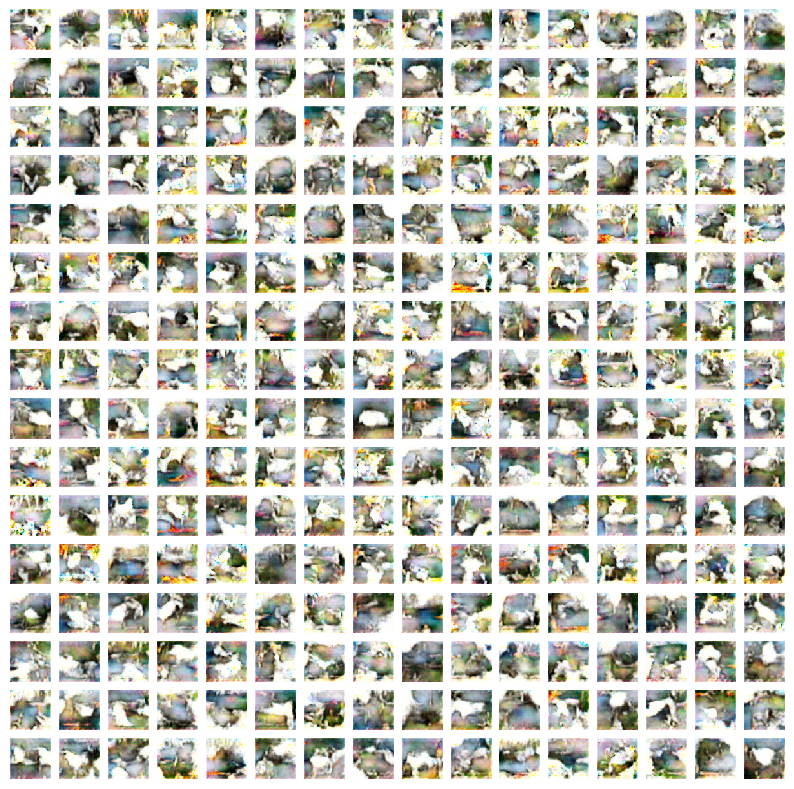

In [34]:
plt.figure(figsize=(10,10))
for i in range(256):
    ax = plt.subplot(16,16,i+1)
    image = generator(torch.randn((1,100,1,1)).to(device))
    plt.imshow(torch.clamp(image,0,1).transpose(1,2).transpose(2,3)[0].detach().cpu().numpy(),interpolation = 'nearest')
    ax.axis("off")
plt.show()

In [33]:
def count_params(model:nn.Module):
    return np.sum([len(i.reshape(-1)) for i in model.parameters()])

In [ ]:
count_params(generator)

As you can see the images, not very different but detailed. But note that the images seemed to share the same colour pallate as the original generator was trained for a small range of colours. This may due to model struggled to arrive in the range \[0,1\].

Moreover,the images are very weird showing that the discriminator struggled to have \[0,1\] range.